<a href="https://colab.research.google.com/github/oninonins/Machine-learning-/blob/main/JS04/Kmeans_murl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re

from urllib.parse import urlparse

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Malicious URL Detection.csv to Malicious URL Detection.csv


In [3]:
df = pd.read_csv("Malicious URL Detection.csv")

print(df.shape)
df.head()

(783705, 2)


,url,type
0,mp3raid.com/music/krizz_kaliko.html,benign
1,bopsecrets.org/rexroth/cr/1.htm,benign
2,buzzfil.net/m/show-art/ils-etaient-loin-de-s-i...,benign
3,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
4,yourbittorrent.com/?q=anthony-hamilton-soulife,benign


In [4]:
print(df["type"].value_counts())

type
benign        426432
phishing      229613
defacement     95263
malware        23592
legitimate      5809
spam            2753
Exploit          243
Name: count, dtype: int64


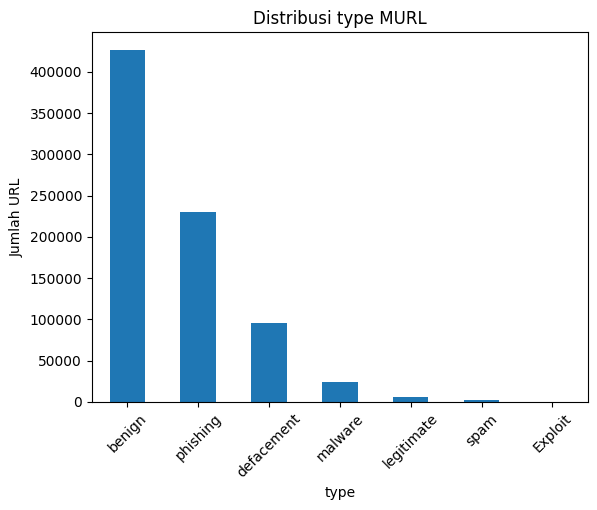

In [5]:
df["type"].value_counts().plot(kind="bar")

plt.title("Distribusi type MURL")
plt.xlabel("type")
plt.ylabel("Jumlah URL")
plt.xticks(rotation=45)
plt.show()

In [8]:
import re
from urllib.parse import urlparse

def extract_url_features(url):
    url = str(url)

    # Default supaya URL yang rusak tetap bisa diproses
    domain = ""
    path = ""

    try:
        parsed = urlparse(
            url if re.match(r"^[a-zA-Z]+://", url) else "//" + url
        )

        domain = parsed.netloc
        path = parsed.path

    except ValueError:
        # Gunakan string URL sebagai dasar ekstraksi fitur
        domain = ""
        path = url

    features = {
        "url_length": len(url),

        "domain_length": len(domain),

        "path_length": len(path),

        "num_digits": sum(c.isdigit() for c in url),

        "num_letters": sum(c.isalpha() for c in url),

        "num_dots": url.count("."),

        "num_slashes": url.count("/"),

        "num_hyphens": url.count("-"),

        "num_underscores": url.count("_"),

        "num_question_marks": url.count("?"),

        "num_equal": url.count("="),

        "num_ampersand": url.count("&"),

        "num_special_chars": sum(
            not c.isalnum() for c in url
        ),

        "num_subdomains": max(domain.count(".") - 1, 0),

        "has_ip": int(
            bool(
                re.match(
                    r"^(?:\d{1,3}\.){3}\d{1,3}$",
                    domain
                )
            )
        ),

        "has_https": int(
            url.lower().startswith("https://")
        )
    }

    return features

In [9]:
features = df["url"].apply(extract_url_features)

X = pd.DataFrame(features.tolist())

X.head()

,url_length,domain_length,path_length,num_digits,num_letters,num_dots,num_slashes,num_hyphens,num_underscores,num_question_marks,num_equal,num_ampersand,num_special_chars,num_subdomains,has_ip,has_https
0,35,11,24,1,29,2,2,0,1,0,0,0,5,0,0,0
1,31,14,17,1,25,2,3,0,0,0,0,0,5,0,0,0
2,111,11,100,1,89,2,3,16,0,0,0,0,21,0,0,0
3,45,11,34,4,31,2,6,1,1,0,0,0,10,1,0,0
4,46,18,1,0,40,1,1,2,0,1,1,0,6,0,0,0


In [11]:
print(X.shape)

(783705, 16)


In [12]:
print(X.isnull().sum())

url_length            0
domain_length         0
path_length           0
num_digits            0
num_letters           0
num_dots              0
num_slashes           0
num_hyphens           0
num_underscores       0
num_question_marks    0
num_equal             0
num_ampersand         0
num_special_chars     0
num_subdomains        0
has_ip                0
has_https             0
dtype: int64


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
print(X_scaled.shape)

(783705, 16)


In [15]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [16]:
df["cluster"] = cluster_labels

df.head(20)

,url,type,cluster
0,mp3raid.com/music/krizz_kaliko.html,benign,0
1,bopsecrets.org/rexroth/cr/1.htm,benign,0
2,buzzfil.net/m/show-art/ils-etaient-loin-de-s-i...,benign,3
3,espn.go.com/nba/player/_/id/3457/brandon-rush,benign,3
4,yourbittorrent.com/?q=anthony-hamilton-soulife,benign,0
5,allmusic.com/album/crazy-from-the-heat-r16990,benign,0
6,corporationwiki.com/ohio/columbus/frank-s-bens...,benign,3
7,myspace.com/video/vid/30602581,benign,0
8,quickfacts.census.gov/qfd/maps/iowa_map.html,benign,0
9,nugget.ca/articledisplay.aspx?archive=true&e=1...,benign,0


In [17]:
#cek
pd.crosstab(
    df["cluster"],
    df["type"]
)

type,Exploit,benign,defacement,legitimate,malware,phishing,spam
cluster,,,,,,,
0,105,295374,37820,5779,14186,188312,2172
1,0,24435,44404,1,765,14709,1
2,0,3249,0,0,2,1125,0
3,0,103349,13039,29,1775,22265,580
4,138,25,0,0,6864,3200,0
5,0,0,0,0,0,2,0


In [18]:
pd.crosstab(
    df["cluster"],
    df["type"],
    normalize="index"
).round(3) * 100

type,Exploit,benign,defacement,legitimate,malware,phishing,spam
cluster,,,,,,,
0,0.0,54.3,7.0,1.1,2.6,34.6,0.4
1,0.0,29.0,52.7,0.0,0.9,17.4,0.0
2,0.0,74.2,0.0,0.0,0.0,25.7,0.0
3,0.0,73.3,9.2,0.0,1.3,15.8,0.4
4,1.3,0.2,0.0,0.0,67.1,31.3,0.0
5,0.0,0.0,0.0,0.0,0.0,100.0,0.0


In [19]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,543748
1,84315
2,4376
3,141037
4,10227
5,2


In [20]:
from sklearn.metrics import silhouette_score
import numpy as np

# Ambil sample 10.000 data
sample_size = 10000

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]
labels_sample = cluster_labels[sample_indices]

# Hitung Silhouette Score
silhouette = silhouette_score(
    X_sample,
    labels_sample
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3729


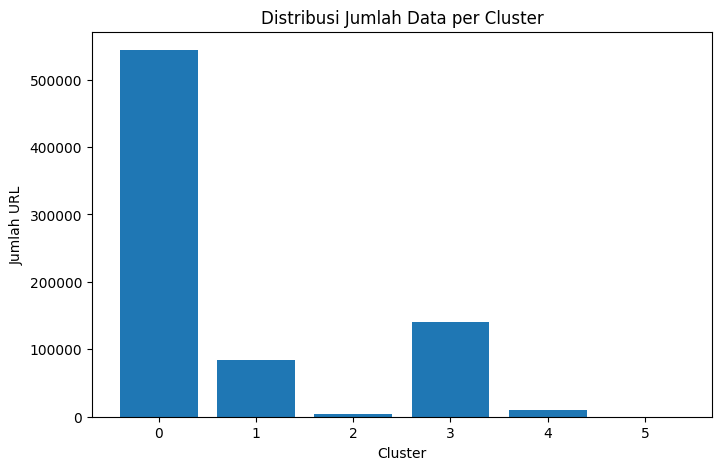

In [21]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Distribusi Jumlah Data per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah URL")

plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_sample)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.3216554  0.16071169]
Total explained variance: 0.48236708327648076


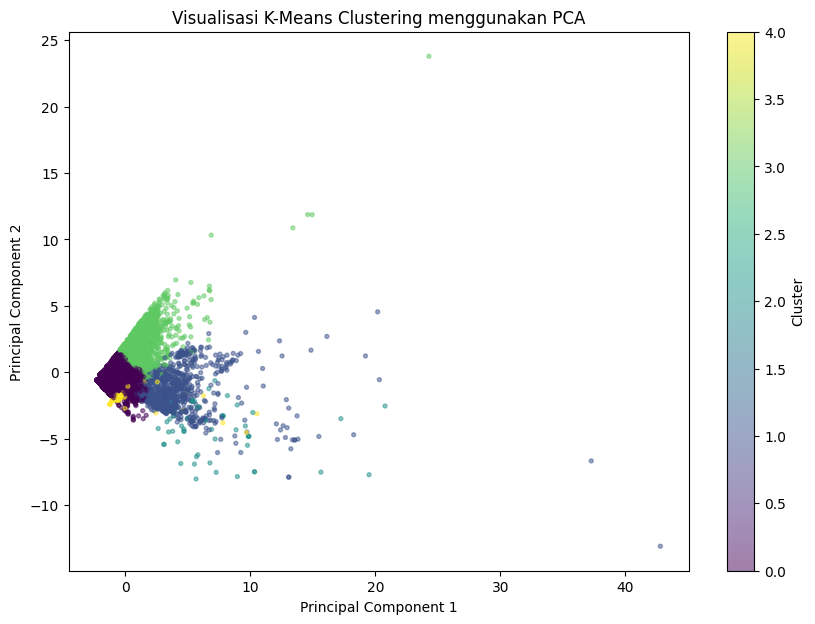

In [23]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_sample,
    s=8,
    alpha=0.5
)

plt.title("Visualisasi K-Means Clustering menggunakan PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

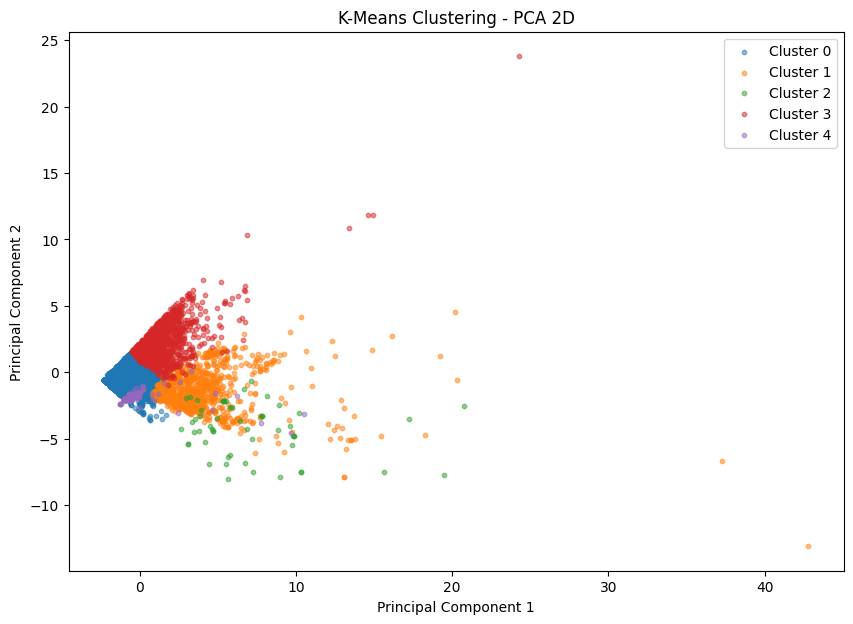

In [24]:
# Ambil maksimal 2000 data dari setiap cluster
visual_df = df.loc[sample_indices, ["url", "type", "cluster"]].copy()

visual_df["PC1"] = X_pca[:, 0]
visual_df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

for cluster in sorted(visual_df["cluster"].unique()):

    subset = visual_df[
        visual_df["cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=10,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.title("K-Means Clustering - PCA 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()